In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import os

from kornia.augmentation.auto.autoaugment.ops import color

from hloc.utils.viz import save_plot

os.environ['PROJ_LIB'] = '/home/lty/anaconda3/envs/hloc/share/proj'

from osgeo import gdal, osr
from geopy.distance import geodesic

from hloc import extract_features, match_features
from hloc.utils.io import get_matches, get_keypoints
from hloc.visualization import plot_images, plot_keypoints, plot_matches, read_image, add_text

/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


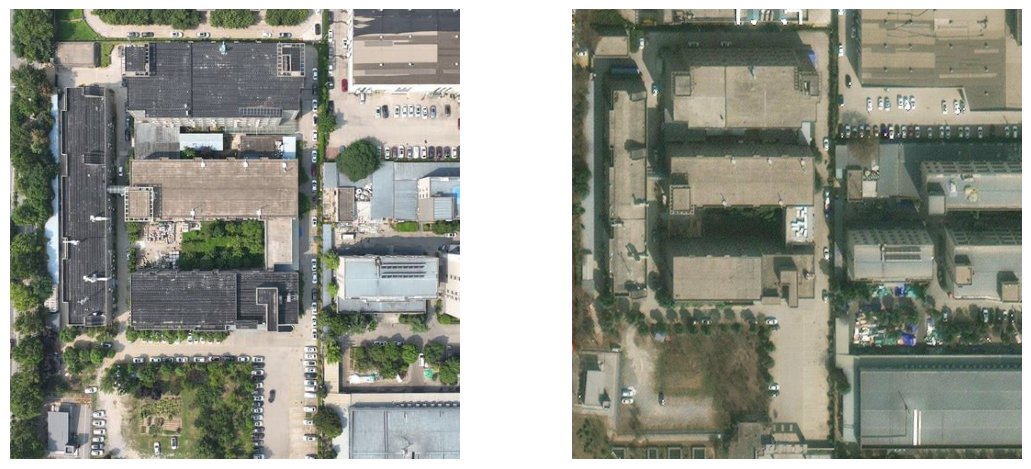

In [3]:
import os
image_dir = Path("/home/lty/code/Hierarchical-Localization/datasets/city3/")
img_1 = "mapping/020.jpg"
img_2 = "tif/146_406_1606.tif"
# img_2 = "seu_uav/DJI_20250109085917_0001_W.JPG"
img_list = [img_1, img_2]
plot_images([read_image(image_dir / img_1), read_image(image_dir / img_2)])

In [4]:
output_dir = Path("output_elevation")
output_dir.mkdir(exist_ok=True, parents=True)
pairs_path = output_dir / "pairs.txt"

# for the first round of feature extraction and matching
features_1_path = output_dir / "features_1.h5"
matches_1_path = output_dir / "matches_1.h5"

In [4]:
# create pairs file
with open(pairs_path, 'w') as file:
    file.write(f"{img_1} {img_2}")

In [5]:
import time
t1 = time.time()
extract_features.main(
    conf=extract_features.confs["superpoint_max"],
    image_dir=image_dir,
    image_list=img_list,
    feature_path=features_1_path,
)
t2 = time.time()
match_features.main(
    conf=match_features.confs["superpoint+lightglue"],
    pairs=pairs_path,
    features=features_1_path,
    matches=matches_1_path,
)
t3 = time.time()
print(f"特征提取耗时：{t2 - t1:.2f} 秒")
print(f"特征匹配耗时：{t3 - t2:.2f} 秒")

[2025/05/13 09:31:44 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}
[2025/05/13 09:31:44 hloc INFO] Skipping the extraction.
[2025/05/13 09:31:44 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2025/05/13 09:31:44 hloc INFO] Skipping the matching.


特征提取耗时：0.01 秒
特征匹配耗时：0.00 秒


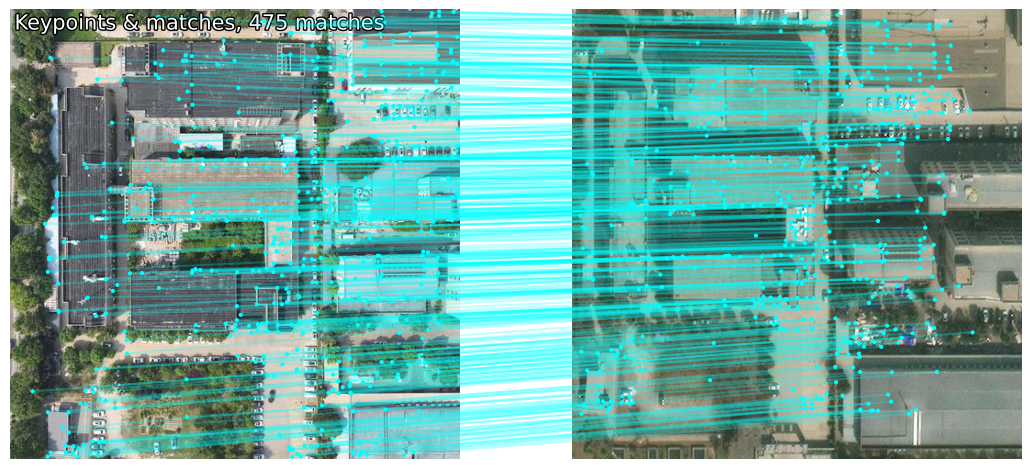

In [5]:
kp1, kp2  = get_keypoints(features_1_path, img_1), get_keypoints(features_1_path, img_2)
matches, scores = get_matches(matches_1_path, img_1, img_2)
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(kp1[matches[:,0]], kp2[matches[:,1]], a=0.25, color=(0, 1, 1))
add_text(0, f"Keypoints & matches, {matches.shape[0]} matches")
#save the plot
plt.savefig("matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

In [19]:
print(kp1.shape)
print(kp2.shape)
print(matches.shape)
print(scores.shape)
kp1

(3931, 2)
(1877, 2)
(475, 2)
(475,)


array([[260.5  ,   2.104],
       [404.2  ,   2.104],
       [466.8  ,   2.104],
       ...,
       [ 74.7  , 487.   ],
       [116.   , 487.   ],
       [306.8  , 487.   ]], dtype=float16)

In [24]:
pts1 = kp1[matches[:,0]]
pts2 = kp2[matches[:,1]]

H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 10.0)#mask:
print(H)
inliers = mask.ravel().tolist()
num_inliers = np.sum(inliers)
print(num_inliers)
# print(mask)

[[ 1.39455537e+00  7.36437258e-02 -2.42843290e+01]
 [ 1.35812379e-02  1.49060137e+00  1.10674135e+01]
 [ 8.84238173e-06  1.76878157e-04  1.00000000e+00]]
224


内点数量：224/475


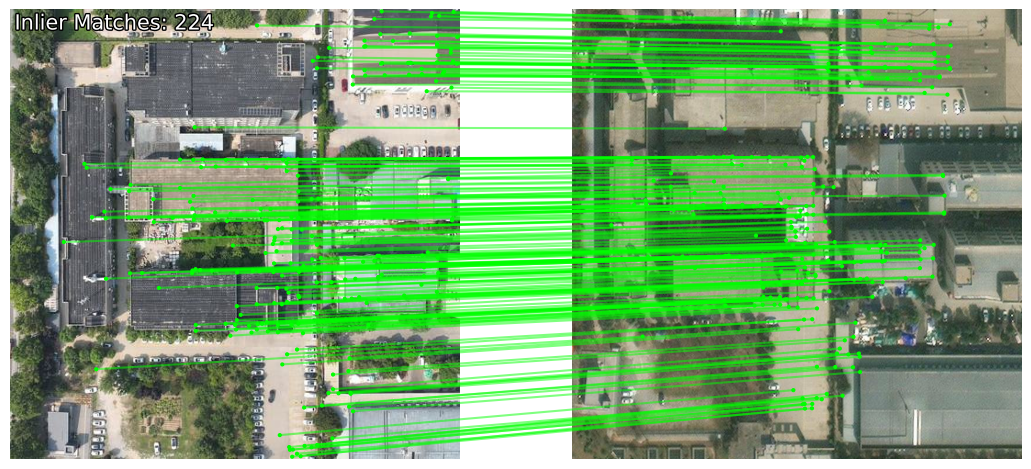

In [40]:
# 将 mask 转换为一维布尔数组
inliers = mask.ravel().astype(bool)

# 提取内点匹配对
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]

# 提取外点匹配对（可选）
pts1_outliers = pts1[~inliers]
pts2_outliers = pts2[~inliers]

# 计算内点数量
num_inliers = np.sum(inliers)
print(f"内点数量：{num_inliers}/{len(pts1)}")

# 可视化内点匹配（例如，使用之前的 plot_matches 函数）
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(pts1_inliers, pts2_inliers, a=0.5, color=(0,1,0))
add_text(0, f"Inlier Matches: {num_inliers}")
plt.savefig("inlier_matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

In [41]:
pts1_inliers

array([[404.2  ,   2.104],
       [482.5  ,   2.715],
       [459.   ,   3.941],
       [466.8  ,   7.004],
       [458.   ,   7.617],
       [396.2  ,  10.375],
       [268.5  ,  17.42 ],
       [434.8  ,  25.98 ],
       [402.8  ,  26.9  ],
       [464.5  ,  28.75 ],
       [486.5  ,  29.97 ],
       [385.5  ,  33.94 ],
       [416.5  ,  34.25 ],
       [464.5  ,  37.94 ],
       [464.5  ,  39.16 ],
       [386.5  ,  40.06 ],
       [385.2  ,  40.38 ],
       [347.   ,  41.9  ],
       [479.8  ,  43.44 ],
       [479.5  ,  47.12 ],
       [465.2  ,  49.88 ],
       [334.8  ,  52.03 ],
       [329.2  ,  56.   ],
       [482.   ,  56.62 ],
       [464.5  ,  57.53 ],
       [433.   ,  58.16 ],
       [434.8  ,  58.16 ],
       [436.   ,  58.16 ],
       [404.8  ,  58.44 ],
       [403.5  ,  59.06 ],
       [486.2  ,  59.06 ],
       [333.8  ,  63.97 ],
       [447.8  ,  64.56 ],
       [385.5  ,  66.1  ],
       [472.2  ,  67.6  ],
       [470.8  ,  69.5  ],
       [448.   ,  70.4  ],
 

In [42]:
pts2_inliers

array([[534.  ,  19.42],
       [644.5 ,  25.66],
       [610.  ,  26.14],
       [625.  ,  30.94],
       [609.5 ,  33.34],
       [521.5 ,  23.73],
       [356.  ,  37.66],
       [576.5 ,  59.75],
       [533.5 ,  58.3 ],
       [616.5 ,  59.75],
       [646.  ,  61.66],
       [510.  ,  65.5 ],
       [553.5 ,  67.44],
       [618.  ,  74.6 ],
       [618.5 ,  76.56],
       [512.  ,  74.6 ],
       [510.  ,  73.2 ],
       [455.2 ,  66.44],
       [641.5 ,  80.9 ],
       [640.5 ,  90.  ],
       [619.5 ,  90.  ],
       [437.5 ,  92.9 ],
       [435.  , 100.06],
       [644.5 , 100.06],
       [618.  , 100.06],
       [574.5 ,  99.1 ],
       [576.  , 100.06],
       [578.  , 100.06],
       [534.  ,  98.1 ],
       [534.  , 100.06],
       [645.  , 102.  ],
       [437.5 , 105.8 ],
       [593.5 , 110.6 ],
       [505.8 , 107.75],
       [627.  , 114.44],
       [627.  , 116.4 ],
       [593.5 , 121.7 ],
       [577.  , 119.25],
       [538.  , 118.3 ],
       [511.5 , 117.3 ],


In [113]:
# translate to geographic coordinates
geotransform = []
# 打开 geotransform.txt 文件
with open("/home/lty/datasets/RealUAV/city3/geotransform.txt", "r") as f:
    # 逐行读取文件内容
    for line in f:
        # 去除行首尾的空白字符和换行符
        line = line.strip()
        if line:
            try:
                # 将字符串转换为浮点数
                value = float(line)
                # 将数值添加到列表中
                geotransform.append(value)
            except ValueError:
                print(f"无法将以下内容转换为数值：'{line}'")
                # 根据需要，可以选择跳过或停止程序
                continue
# 输出读取到的 geotransform 数据
print("Geotransform 数组：\n", geotransform)
tif_name = os.path.basename(img_2)
print(tif_name)
start_x = start_y = None
# 使用正则表达式匹配以数字开头的部分
match = re.match(r"(\d+)_(\d+)_(\d+).tif", tif_name)
if match:
    tif_id = match.group(1)
    start_x = match.group(2)
    start_y = match.group(3)
    print(f"TIFF ID: {tif_id}")
    print(f"起始横坐标：{start_x}")
    print(f"起始纵坐标：{start_y}")
else:
    print("无法从文件名中提取 TIFF ID")
    


x_geo, y_geo = None, None
pts2_inliers_geo = np.zeros((len(pts2_inliers), 2))

# 保存转换后的地理坐标
# --------------------------
geo_out_path = output_dir / "satellite_inlier_points_with_geo.txt"
# 获取仿射变换参数
x_origin, x_pixel_size, x_rotation, y_origin, y_rotation, y_pixel_size = geotransform

lu_geox = x_origin + float(start_x) * x_pixel_size
lu_geoy = y_origin + float(start_y) * y_pixel_size

with open(geo_out_path, 'w') as f:
    for idx, (x_pix, y_pix) in enumerate(pts2_inliers): 
        x_in_map = int(start_x) + x_pix
        y_in_map = int(start_y) + y_pix
        
        x_geo = x_origin + x_in_map * x_pixel_size
        y_geo = y_origin + y_in_map * y_pixel_size
        x_geo = x_geo-lu_geox
        y_geo = lu_geoy-y_geo
        
        pts2_inliers_geo[idx, 0] = x_geo
        pts2_inliers_geo[idx, 1] = y_geo
        
        
        f.write(f"{idx} {x_pix:.2f} {y_pix:.2f} {x_geo:.8f} {y_geo:.8f}\n")

Geotransform 数组：
 [12117256.345935825, 0.2985821417389691, 0.0, 4055825.1578397285, 0.0, -0.2985821417389691]
146_406_1606.tif
TIFF ID: 146
起始横坐标：406
起始纵坐标：1606


In [ ]:
print(pts2_inliers_geo)

In [47]:
print(start_x,start_y)

406 1606


In [86]:
# 指定输出文件路径
match_save_path = output_dir / "satellite_uav_inliers.txt"

# 打开文件写入模式
with open(match_save_path, 'w') as f:
    for idx, (pt2_geo, pt2, pt1) in enumerate(zip(pts2_inliers_geo, pts2_inliers, pts1_inliers)):
        # pt2: 卫星影像特征点（目标图像）
        # pt1: 无人机影像特征点（参考图像）
        x2_geo, y2_geo = pt2_geo
        x2, y2 = pt2  # 卫星影像
        x1, y1 = pt1  # 无人机影像
        # 写入格式：索引 x2 y2 x1 y1
        f.write(f"{idx} {x2_geo:.8f} {y2_geo:.8f} {x2:.2f} {y2:.2f} {x1:.2f} {y1:.2f}\n")

print(f"内点匹配信息已保存至 {match_save_path}")


内点匹配信息已保存至 output_elevation/satellite_uav_inliers.txt


In [ ]:
from hloc.utils.read_write_model import read_model
cameras, images, points3D = read_model('/home/lty/code/Hierarchical-Localization/outputs/city3/sfm')

In [87]:
from scipy.spatial import cKDTree
import numpy as np

def find_3d_points_with_ids_for_uav_inliers(pts1_inliers, images, image_id, points3D, pixel_thresh=2.0):
    """
    给定 UAV 图像的内点 pts1_inliers，找到在 COLMAP 中对应的三维点，并返回所有关联信息。

    返回：
        matched_ids       : 原始内点的索引（int）
        matched_2d        : UAV图像中的2D坐标 (N, 2)
        matched_3d        : 对应的三维空间坐标 (N, 3)
        matched_3d_ids    : 对应的3D点ID (N,)
    """
    image = images[image_id]
    xys_colmap = image.xys  # COLMAP 特征点坐标
    point3D_ids = image.point3D_ids  # 对应的3D点ID

    tree = cKDTree(xys_colmap)

    matched_ids = []
    matched_2d = []
    matched_3d = []
    matched_3d_ids = []

    for i, pt in enumerate(pts1_inliers):
        dist, idx = tree.query(pt, distance_upper_bound=pixel_thresh)

        # print(f"pt: {pt}, dist: {dist}")  # 输出距离以调试

        if idx < len(xys_colmap):
            pid = point3D_ids[idx]
            if pid != -1 and pid in points3D:
                xyz = points3D[pid].xyz
                matched_ids.append(i)            # 当前点在 pts1_inliers 中的索引
                matched_2d.append(pt)            # UAV像素点
                matched_3d.append(xyz)           # 对应3D点坐标
                matched_3d_ids.append(pid)       # 对应3D点ID

    matched_ids = np.array(matched_ids)
    matched_2d = np.array(matched_2d)
    matched_3d = np.array(matched_3d)
    matched_3d_ids = np.array(matched_3d_ids)

    print(f"\n共找到 {len(matched_3d)} 个有效2D-3D匹配点")
    return matched_ids, matched_2d, matched_3d, matched_3d_ids


image_id = 20  # 替换为你实际使用的无人机图像编号

matched_ids, matched_2d, matched_3d, matched_3d_ids = find_3d_points_with_ids_for_uav_inliers(
    pts1_inliers, images, image_id, points3D=points3D, pixel_thresh=1.0
)

# 保存为 csv 或 txt 格式
save_path = output_dir/"uav_2d_to_3d_matches.txt"
with open(save_path, 'w') as f:
    f.write("match_id uav_x uav_y X Y Z point3D_id\n")
    for i in range(len(matched_ids)):
        idx = matched_ids[i]
        x2d, y2d = matched_2d[i]
        X, Y, Z = matched_3d[i]
        pid = matched_3d_ids[i]
        f.write(f"{idx} {x2d:.2f} {y2d:.2f} {X:.6f} {Y:.6f} {Z:.6f} {pid}\n")


共找到 211 个有效2D-3D匹配点


In [ ]:
matched_satellite_geos = pts2_inliers_geo[matched_ids]

In [96]:
def estimate_scale_least_squares_centered(geo_coords, model_coords):
    geo_center = np.mean(geo_coords, axis=0)
    model_center = np.mean(model_coords, axis=0)

    geo_zero = geo_coords - geo_center
    model_zero = model_coords - model_center

    numerator = np.sum(geo_zero * model_zero)
    denominator = np.sum(model_zero ** 2)

    if denominator < 1e-8:
        raise ValueError("地理坐标值过小或全相同，无法估计尺度")

    scale = numerator / denominator
    return scale

# matched_satellite_geos: (N, 2)
# matched_3d: (N, 3)
model_xy = matched_3d[:, :2]

scale = estimate_scale_least_squares_centered(matched_satellite_geos, model_xy)
print(f"估计得到的最优尺度因子: {scale}")

估计得到的最优尺度因子: 10.668092990702199


In [ ]:
def estimate_ground_z_flipped(Z_scaled, method='quantile', quantile=0.95):
    """
    用于原始 Z 是从空中指向地面的情况（Z越大越靠近地面）。
    """
    if method == 'max':
        return np.max(Z_scaled)
    elif method == 'quantile':
        return np.quantile(Z_scaled, quantile)
    elif method == 'mean':
        return np.mean(Z_scaled)
    else:
        raise ValueError("method must be 'quantile', 'max', or 'mean'")

def convert_model_z_to_geo_flipped(Z_model, scale, method='quantile', quantile=0.95):
    Z_scaled = Z_model * scale
    Z_ground = estimate_ground_z_flipped(Z_scaled, method, quantile)
    Z_final = Z_ground - Z_scaled  # 让地面为0，Z值越小越靠近相机
    return Z_final, Z_ground

Z_model = matched_3d[:, 2]
Z_final, Z_ground = convert_model_z_to_geo_flipped(Z_model, scale)

print(f"估计地面Z = {Z_ground:.3f}")
print(f"Z_final范围: {Z_final.min():.2f} ~ {Z_final.max():.2f}")

# 升维构造完整三维地理点：
satellite_3d_final = np.hstack([matched_satellite_geos, Z_final[:, np.newaxis]])
print(f"地面高度估计值: {Z_ground:.4f}")
print(satellite_3d_final)

In [108]:
output_path = output_dir / "satellite_3d_final.txt"
def save_3d_points_txt(points_3d, output_path):
    with open(output_path, 'w') as f:
        f.write("X_geo Y_geo Z_height\n")
        for pt in points_3d:
            f.write(f"{pt[0]:.3f} {pt[1]:.3f} {pt[2]:.3f}\n")
    print(f"已保存至：{output_path}")

save_3d_points_txt(satellite_3d_final, output_path)

已保存至：output_elevation/satellite_3d_final.txt


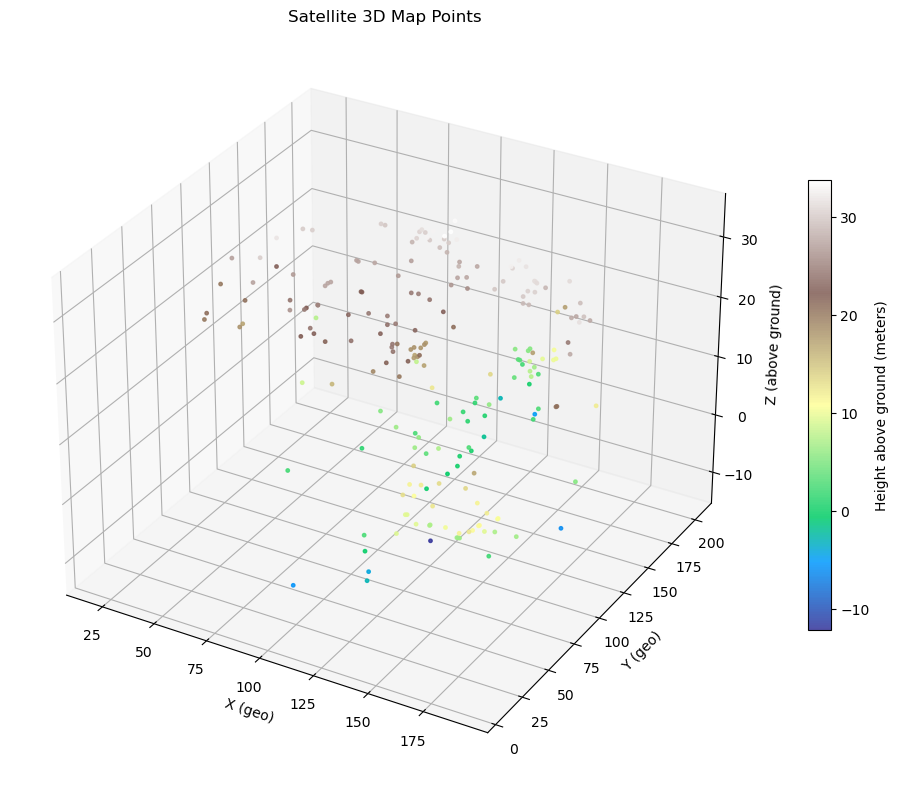

In [111]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def visualize_3d_geopoints(points_3d, elev_cmap='terrain', elev_alpha=0.85, elev_pointsize=6):
    """
    三维点可视化：X_geo, Y_geo, Z_above_ground
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    x = points_3d[:, 0]
    y = points_3d[:, 1]
    z = points_3d[:, 2]

    # 高度颜色映射
    sc = ax.scatter(x, y, z, c=z, cmap=elev_cmap, alpha=elev_alpha, s=elev_pointsize)

    # 添加颜色条
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label('Height above ground (meters)')

    ax.set_xlabel('X (geo)')
    ax.set_ylabel('Y (geo)')
    ax.set_zlabel('Z (above ground)')
    ax.set_title('Satellite 3D Map Points')

    plt.tight_layout()
    plt.show()
    
visualize_3d_geopoints(satellite_3d_final)

# 可视化三维地理点

/tmp/ipykernel_26459/3779197403.py:7: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_26459/3779197403.py:7: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_26459/3779197403.py:7: UserWarning: Glyph 20110 (\N{CJK UNIFIED IDEOGRAPH-4E8E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_26459/3779197403.py:7: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_26459/3779197403.py:7: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from current font.
  plt.tight_layout()
/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/IPyth

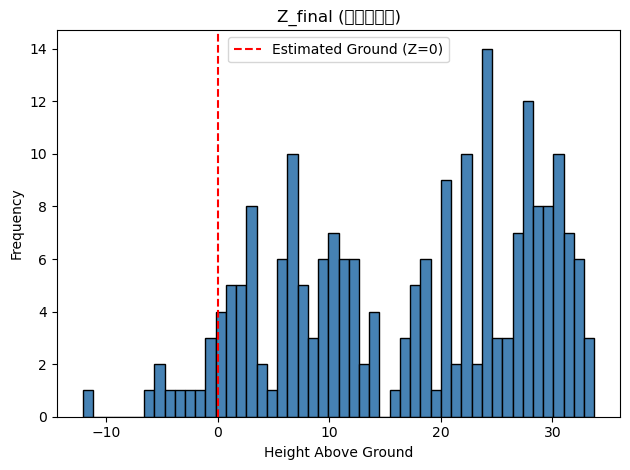

In [109]:
plt.hist(Z_final, bins=50, color='steelblue', edgecolor='k')
plt.axvline(0, color='red', linestyle='--', label="Estimated Ground (Z=0)")
plt.title("Z_final (相对于地面)")
plt.xlabel("Height Above Ground")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()



In [94]:
import numpy as np
def estimate_scale_from_random_pairs(geo_coords, model_coords, num_pairs=1000, seed=None):
    """
    随机采样点对，使用二维距离比来估计尺度因子。

    参数：
        geo_coords: (N, 2) 卫星地理坐标点
        model_coords: (N, 2) 对应的UAV模型坐标点
        num_pairs: 采样的点对数量
        seed: 随机种子（可选）

    返回：
        scale_mean: 所有采样点对的尺度因子平均值
        scale_std:  标准差（用于衡量尺度估计的稳定性）
        scale_list: 所有计算出的 scale 值列表
    """
    assert geo_coords.shape == model_coords.shape
    N = geo_coords.shape[0]
    assert N >= 2, "至少需要两个点"

    if seed is not None:
        np.random.seed(seed)

    scales = []

    for _ in range(num_pairs):
        i, j = np.random.choice(N, 2, replace=False)

        d_geo = np.linalg.norm(geo_coords[i] - geo_coords[j])
        d_model = np.linalg.norm(model_coords[i] - model_coords[j])

        # 排除无效点对（距离太小）
        if d_geo > 1e-6 and d_model > 1e-6:
            scales.append(d_model / d_geo)

    if len(scales) == 0:
        raise ValueError("所有随机点对都无效，无法估计尺度")

    scale_mean = np.mean(scales)
    scale_std = np.std(scales)
    return scale_mean, scale_std, scales

geo_coords = matched_satellite_geos     # (N, 2)
model_coords = matched_3d[:, :2]        # (N, 2)

scale_mean, scale_std, scale_list = estimate_scale_from_random_pairs(
    geo_coords, model_coords, num_pairs=1000, seed=42
)

print(f"随机点对估计尺度：mean = {scale_mean:.6f}, std = {scale_std:.6f}")

随机点对估计尺度：mean = 0.094440, std = 0.007517


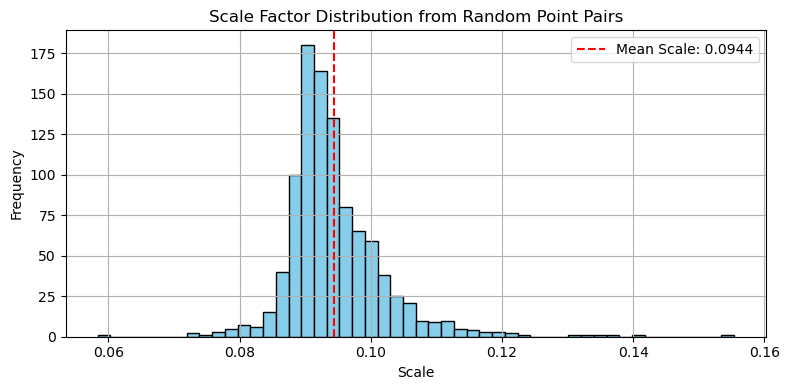

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(scale_list, bins=50, color='skyblue', edgecolor='k')
plt.axvline(scale_mean, color='red', linestyle='--', label=f"Mean Scale: {scale_mean:.4f}")
plt.title("Scale Factor Distribution from Random Point Pairs")
plt.xlabel("Scale")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("scale_distribution.png")
plt.show()


In [52]:
print(images)

{1: Image(id=1, qvec=array([ 9.99903411e-01,  1.36587508e-02, -4.58350189e-04, -2.52941285e-03]), tvec=array([-0.48043701, -6.24848373, -0.18996266]), camera_id=1, name='mapping/001.jpg', xys=array([[159.75      ,   2.60351562],
       [264.25      ,   2.60351562],
       [357.5       ,   2.60351562],
       ...,
       [174.75      , 487.        ],
       [ 41.5       , 487.5       ],
       [ 43.03125   , 487.5       ]]), point3D_ids=array([5551,  156, 4642, ...,   -1,   -1,   -1])), 2: Image(id=2, qvec=array([ 9.99899249e-01,  1.41620850e-02, -9.44254170e-04, -1.86420419e-04]), tvec=array([-0.41977217, -6.05341474, -0.1869615 ]), camera_id=2, name='mapping/002.jpg', xys=array([[130.875     ,   2.60351562],
       [134.625     ,   2.60351562],
       [167.375     ,   2.60351562],
       ...,
       [380.        , 487.5       ],
       [392.75      , 487.5       ],
       [485.25      , 487.5       ]]), point3D_ids=array([2632,  343, 7716, ...,   -1,   -1,   -1])), 3: Image(id=3, qvec

In [50]:
print(points3D)

{11433: Point3D(id=11433, xyz=array([-1.70438497, -2.39314798, 39.67596548]), rgb=array([91, 84, 78]), error=array(2.24516056), image_ids=array([13, 20, 12, 17, 21,  6,  5, 13,  4, 21,  5, 24]), point2D_idxs=array([1055, 1656,  874, 1368, 1684,  365,  266, 1089,   83, 1750,  291,
       2059])), 11431: Point3D(id=11431, xyz=array([ 4.81405846, -0.19410898, 41.42787845]), rgb=array([148, 143, 143]), error=array(2.37052214), image_ids=array([ 8, 23, 10, 15, 16, 14, 13, 12, 11, 18, 17, 19, 20, 21,  9, 22,  7,
        6,  5,  4,  3,  2,  1, 23, 10, 15, 16, 14, 13, 12, 11, 18, 17, 17,
       19, 20, 20, 21, 21,  9, 22,  1, 24, 24]), point2D_idxs=array([  69, 2366, 1338, 1717, 1854, 1547, 1613, 1461, 1393, 2041, 1869,
       2055, 2167, 2170, 1158, 2299,  328,  933,  838,  647,  497,  362,
        304, 2410, 1376, 1750, 1898, 1586, 1643, 1487, 1427, 2078, 1900,
       1903, 2085, 2199, 2212, 2213, 2217, 1180, 2330,  349, 2500, 2497])), 11430: Point3D(id=11430, xyz=array([ 0.58617332, 13.2216

In [51]:
print(cameras)

{1: Camera(id=1, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06055007e+03, 2.45000000e+02, 2.45000000e+02, 1.24624091e-01])), 2: Camera(id=2, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06086373e+03, 2.45000000e+02, 2.45000000e+02, 1.19332614e-01])), 3: Camera(id=3, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06183579e+03, 2.45000000e+02, 2.45000000e+02, 1.21027642e-01])), 4: Camera(id=4, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06061524e+03, 2.45000000e+02, 2.45000000e+02, 1.23271649e-01])), 5: Camera(id=5, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06056453e+03, 2.45000000e+02, 2.45000000e+02, 1.26673794e-01])), 6: Camera(id=6, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.05968229e+03, 2.45000000e+02, 2.45000000e+02, 1.26266489e-01])), 7: Camera(id=7, model='SIMPLE_RADIAL', width=490, height=490, params=array([1.06314883e+03, 2.45000000e+02, 2.45000000e+02, 1.23839552e-01]))